In [2]:
import numpy as np
import pint
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
unit = pint.UnitRegistry()

magnitude = lambda x: x.magnitude if isinstance(x, pint.Quantity) else x
tounit = lambda x: lambda y: y.to(x)
assign_unit = lambda x: lambda y: y * x
assign_quantitiy = lambda t, quantity: unit.Quantity(t, quantity)

In [3]:
data1 = pd.read_csv('../DATA/table1.csv')
data2 = pd.read_csv('../DATA/table2.csv')

In [149]:
data1

,I(mA),V(mV)
0,100,21
1,141,30


In [150]:
data2

,V(V),I(A),U(mV)
0,1.00,1.66,140
1,2.00,2.54,530
2,2.96,3.07,1370
3,3.64,3.41,2200
4,4.36,3.77,3300
5,4.78,4.00,4070
6,5.68,4.42,6000


In [4]:
# convert data1 to SI units
data1['I(A)'] = data1['I(mA)'].apply(assign_unit(unit.mA)).apply(tounit(unit.A))
data1['V(V)'] = data1['V(mV)'].apply(assign_unit(unit.mV)).apply(tounit(unit.V))
data1 = data1.drop(columns=['I(mA)', 'V(mV)'])

In [5]:
# clean obvious outliers (e.g. I(A) > 100 which are likely typos)
data2 = data2[data2['I(A)'] < 100].copy()

data2['V(V)'] = data2['V(V)'].apply(assign_unit(unit.V)).apply(tounit(unit.V))
data2['I(A)'] = data2['I(A)'].apply(assign_unit(unit.A)).apply(tounit(unit.A))

In [153]:
data2

,V(V),I(A),U(mV)
0,1.0 volt,1.66 ampere,140
1,2.0 volt,2.54 ampere,530
2,2.96 volt,3.07 ampere,1370
3,3.64 volt,3.41 ampere,2200
4,4.36 volt,3.77 ampere,3300
5,4.78 volt,4.0 ampere,4070
6,5.68 volt,4.42 ampere,6000


In [154]:
data1

,I(A),V(V)
0,0.1 ampere,0.021 volt
1,0.14100000000000001 ampere,0.03 volt


In [155]:
data1

,I(A),V(V)
0,0.1 ampere,0.021 volt
1,0.14100000000000001 ampere,0.03 volt


In [6]:
data1['R_room(Ohm)'] = (data1['V(V)'] / data1['I(A)']).apply(tounit(unit.ohm))
R_room_average = data1["R_room(Ohm)"].apply(magnitude).mean() * unit.ohm
R_room_average

<Quantity(0.211382979, 'ohm')>

In [7]:
alpha = 4.82e-3 * unit.K**-1
beta = 6.76e-7 * unit.K**-2
t_room = 20 # C
R_0 = (R_room_average / (1 + alpha.magnitude * t_room + beta.magnitude * t_room**2))
R = lambda t: R_0 * (1 + alpha * t + beta * t**2)
T = lambda R, R_0: 273*unit.K + 1/(2*beta) * ( - alpha + np.sqrt(alpha**2 - 4*beta*(1 - R/R_0)))
R_0

<Quantity(0.19274978, 'ohm')>

In [8]:

data2["Rt(t)(ohm)"] = data2["V(V)"] / data2["I(A)"]
data2["T(K)"] = data2["Rt(t)(ohm)"].apply(lambda R: T(R, R_0))
data2

,V(V),I(A),U(mV),Rt(t)(ohm),T(K)
0,1.0 volt,1.66 ampere,140,0.6024096385542169 volt / ampere,689.6018273579091 kelvin
1,2.0 volt,2.54 ampere,530,0.7874015748031495 volt / ampere,864.0646325790453 kelvin
2,2.96 volt,3.07 ampere,1370,0.9641693811074918 volt / ampere,1024.1879539921342 kelvin
3,3.64 volt,3.41 ampere,2200,1.067448680351906 volt / ampere,1115.050750768085 kelvin
4,4.36 volt,3.77 ampere,3300,1.156498673740053 volt / ampere,1191.9169838800321 kelvin
5,4.78 volt,4.0 ampere,4070,1.195 volt / ampere,1224.7455608477183 kelvin
6,5.68 volt,4.42 ampere,6000,1.2850678733031673 volt / ampere,1300.6264513799617 kelvin


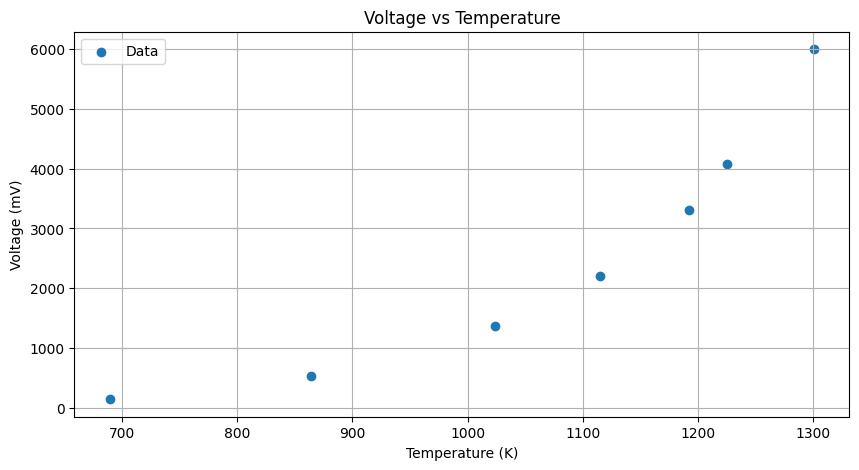

In [ ]:
import os
os.makedirs("../plots", exist_ok=True)
plt.figure(figsize=(10, 5))

plt.scatter(data2["T(K)"].apply(magnitude), data2["U(mV)"].apply(magnitude), label="Data")
plt.xlabel("Temperature (K)")  
plt.ylabel("Voltage (mV)")
plt.grid()
plt.title("Voltage vs Temperature")
plt.legend()
plt.savefig("../plots/plot1.png")
plt.show()

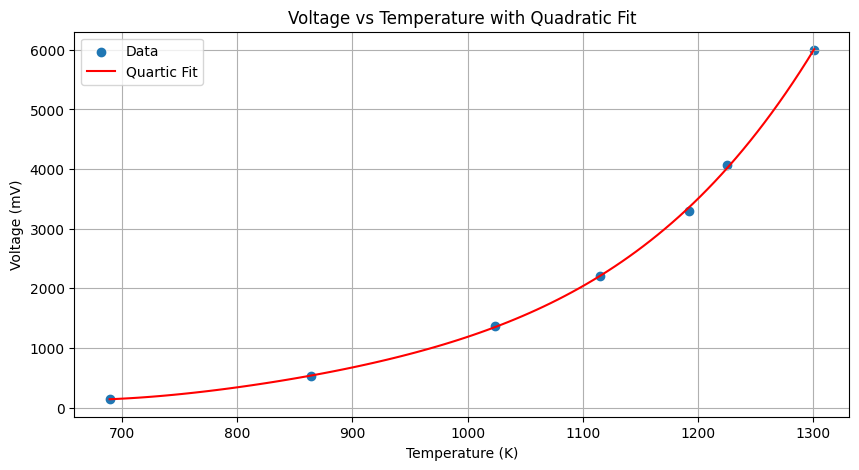

In [ ]:
# quadratic regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
X = data2["T(K)"].apply(magnitude).values.reshape(-1, 1)
y = data2["U(mV)"].apply(magnitude).values
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, y)
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_line_poly = poly.transform(X_line)
y_pred = model.predict(X_line_poly)
plt.figure(figsize=(10, 5))
plt.scatter(X, y, label="Data")
plt.plot(X_line, y_pred, color='red', label="Quartic Fit")
plt.xlabel("Temperature (K)")
plt.ylabel("Voltage (mV)")
plt.grid()
plt.title("Voltage vs Temperature with Quartic Fit")
plt.legend()
plt.savefig("../plots/plot2.png")
plt.show()

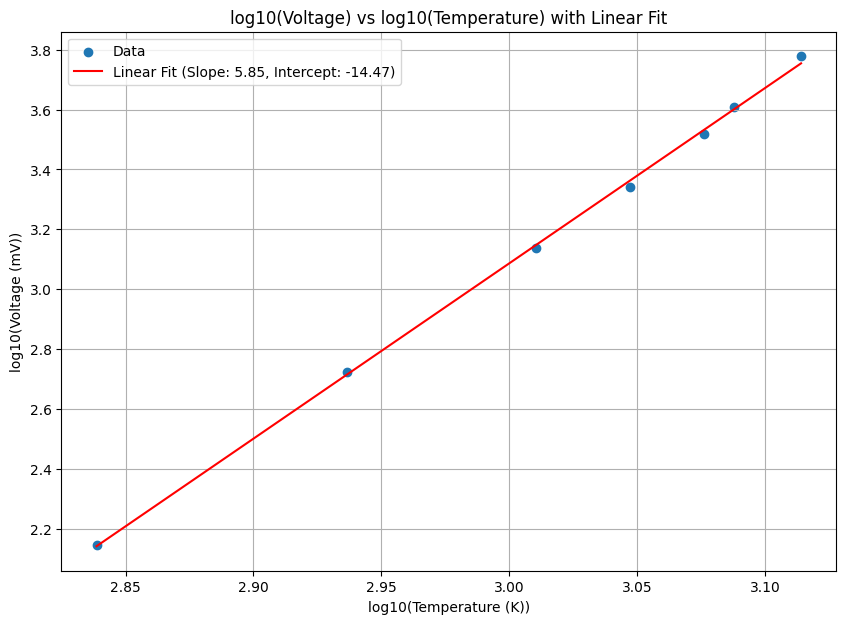

In [11]:
# linear fit of the log_10 to find log U = 4 log T + constant
from sklearn.linear_model import LinearRegression
X_log = np.log10(data2["T(K)"].apply(magnitude).values).reshape(-1, 1)
y_log = np.log10(data2["U(mV)"].apply(magnitude).values)

log_model = LinearRegression()
log_model.fit(X_log, y_log)
X_line_log = np.linspace(X_log.min(), X_log.max(), 1000).reshape(-1, 1)
y_pred_log = log_model.predict(X_line_log)

plt.figure(figsize=(10, 7))
plt.scatter(X_log, y_log, label="Data")
plt.plot(X_line_log, y_pred_log, color='red', label=f"Linear Fit (Slope: {log_model.coef_[0]:.2f}, Intercept: {log_model.intercept_:.2f})")
plt.xlabel("log10(Temperature (K))")
plt.ylabel("log10(Voltage (mV))")
plt.grid()
plt.title("log10(Voltage) vs log10(Temperature) with Linear Fit")
plt.legend()
plt.savefig("../plots/plot3.png")
plt.show()

In [12]:
log_model.coef_[0]

5.851609086492177

In [9]:
import os
os.makedirs("../report/tables", exist_ok=True)
data1_export = data1.copy()
for col in data1_export.columns:
    if hasattr(data1_export[col].iloc[0], 'magnitude'):
        data1_export[col] = data1_export[col].apply(magnitude)
    # Format to 4 significant figures
    data1_export[col] = data1_export[col].apply(lambda x: '{:.4g}'.format(x) if isinstance(x, (int, float)) else x)
data1_export.to_csv("../report/tables/data1.csv", index=False)

data2_export = data2.copy()
for col in data2_export.columns:
    if hasattr(data2_export[col].iloc[0], 'magnitude'):
        data2_export[col] = data2_export[col].apply(magnitude)
    # Format to 4 significant figures
    data2_export[col] = data2_export[col].apply(lambda x: '{:.4g}'.format(x) if isinstance(x, (int, float)) else x)
data2_export.to_csv("../report/tables/data2.csv", index=False)
print("Data exported successfully.")

Data exported successfully.
